# Ovarian Cancer Biomarker Discovery with RobustModelMaker

**Dataset:** PLCO Trial serum biomarker panels (Prostate, Lung, Colorectal and Ovarian Cancer Screening Trial)  
**Task:** Binary classification -- distinguish ovarian cancer cases from matched controls  
**Samples:** 1,069 &nbsp;|&nbsp; **Features:** 42 &nbsp;|&nbsp; **Target:** `is_case` (1 = cancer, 0 = control)

---

## Why this dataset?

Ovarian cancer has poor survival largely because it is detected late. Identifying it from serum biomarkers measured before diagnosis could enable earlier intervention. CA-125 is the standard single-biomarker test, but it has limited sensitivity and specificity in early-stage disease. The PLCO trial tested whether panels of additional biomarkers could improve discrimination.

The 42 features span five panels (A through E) measured using different immunoassay technologies. The same biomarker often appears in more than one panel (CA-125 appears in panels A, B, C, and E under different assay platforms; HE4 appears in panels B, C, and E). Panel C also includes log-transformed versions of its raw measurements alongside the originals. The feature space is therefore characterised by substantial within-panel and cross-panel redundancy -- exactly the setting where bootstrap stability selection adds the most value by identifying which specific assay version and which additional biomarkers are *consistently* discriminative.

**Clinical context:**
- **Class imbalance is inherent:** ovarian cancer cases are rare in a screening population (here ~11%). RobustModelMaker handles this internally via balanced class weighting.
- **The cutoff matters clinically:** AUC measures discrimination; the probability threshold determines the sensitivity/specificity trade-off at which a clinical test operates. RobustModelMaker determines a specificity-targeted cutoff via bootstrap.
- **Reproducibility is essential:** a biomarker panel selected from a single run may not replicate. Stability selection identifies the panel that survives resampling of the training data.

**What we expect ROBUST to do here:**
- Select a small, stable subset of the 42 biomarkers
- Identify which panel(s) and which assay versions carry the most consistent discriminative signal
- Produce a nested CV AUC estimate that is honest (no leakage into the test set)
- Determine a probability cutoff targeted at clinically acceptable specificity

Ethical approvals for this study was obtained from ANU Human Research Ethics Committee (Protocol 2022/261). 

## 1. Installation and imports

```bash
pip install robustmodelmaker xgboost
```

In [3]:
import os
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from xgboost import XGBClassifier

from robustmodelmaker import RobustModelMaker

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

print('Imports OK')

Imports OK


## 2. Load the dataset

The CSV is in the same directory as this notebook. It contains 1,069 serum samples from the PLCO trial: 118 ovarian cancer cases and 951 matched controls. All 42 feature columns are continuous biomarker concentrations; missing values are present throughout (2-24 per column) and are handled by ROBUST's internal median imputation.

The five biomarker panels are:

| Panel | Technology focus | Biomarkers |
|---|---|---|
| A | Growth factors / cytokines | Leptin, prolactin, OPN, IGF-II, MIF, CA-125 |
| B | Cancer antigens + HE4 | CA125, CA15-3, CA19-9, CA72-4, KLK6, HE4, OV-110 |
| C | Mesothelin panel (raw + log) | CA125, HE4, mesothelin, MMP7, IGFBP-II, spondin-2, SLPI (x2) |
| D | Acute-phase / proteomics | HepC, ITIH4, CTAP, TT, TRF, B2M, APO |
| E | Cytokines / CA-125 retest | Eotaxin, MMP-3, EGFR, CA72-4, prolactin, HE4, CA-125 (Fujirebio) |

#### IMPORTANT NOTICE: This data set is not provided with the notebook. 
Ethical approvals for this study was obtained from ANU Human Research Ethics Committee (Protocol 2022/261). You will need to obtain permisson to access this data set yourself, from here: https://cdas.cancer.gov/datasets/plco/23/ 

In [6]:
df = pd.read_csv('PLCO_ovarian_cancer.csv')

print(f'Shape: {df.shape[0]:,} samples x {df.shape[1]} columns')
print()
print('Class distribution (is_case):')
vc = df['is_case'].value_counts().sort_index()
for val, count in vc.items():
    label = 'case (ovarian cancer)' if val == 1 else 'control'
    print(f'  {val} = {label}: {count} ({count/len(df):.1%})')
print()
print('Missing values per feature:')
mv = df.drop(columns=['is_case']).isnull().sum()
print(mv[mv > 0].to_string())

Shape: 1,069 samples x 43 columns

Class distribution (is_case):
  0 = control: 951 (89.0%)
  1 = case (ovarian cancer): 118 (11.0%)

Missing values per feature:
panela_leptin                 9
panela_prolactin              9
panela_opn                    9
panela_igf_ii                 9
panela_mif                    9
panela_ca_125                 9
panelb_ca125                 20
panelb_ca15_3                21
panelb_ca19_9                20
panelb_ca72_4                24
panelb_klk6                  24
panelb_he4                    5
panelb_ov_110                 2
panelc_ca125                  8
panelc_he4                    8
panelc_mesothelin             8
panelc_mmp7                   8
panelc_igfbpii_ng_ml          8
panelc_igfbpii_nml_lp         9
panelc_spondin2               8
panelc_slpi                   8
panelc_ca125_log              8
panelc_he4_log                8
panelc_mesothelin_log         8
panelc_mmp7_sd_log            8
panelc_igfbpii_nml_lp_log     9
panelc

## 3. Exploratory data analysis

Class imbalance is immediately apparent: controls outnumber cases 8:1. CA-125 (the standard biomarker) already shows strong separation between classes on a log scale, but substantial overlap remains -- motivating the multi-panel approach.

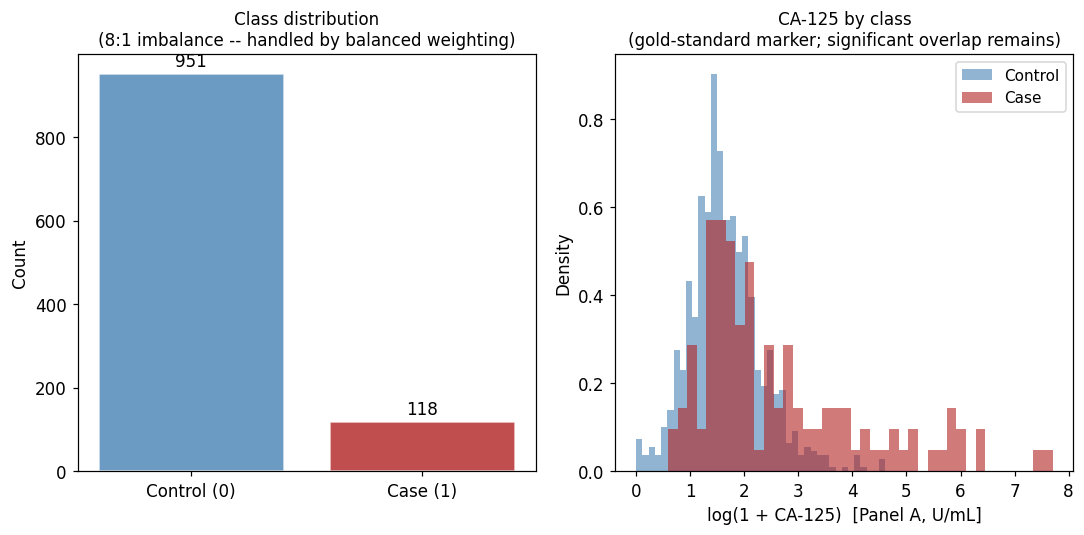

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Class distribution
ax = axes[0]
counts = df['is_case'].value_counts().sort_index()
bars = ax.bar(['Control (0)', 'Case (1)'], counts.values,
              color=['steelblue', 'firebrick'], alpha=0.8, edgecolor='white')
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8, str(count),
            ha='center', va='bottom', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Class distribution\n(8:1 imbalance -- handled by balanced weighting)', fontsize=11)
ax.tick_params(labelsize=11)

# CA-125 distribution by class (log scale)
ax = axes[1]
ca125 = df[['is_case', 'panela_ca_125']].dropna()
controls_ca = ca125[ca125['is_case'] == 0]['panela_ca_125']
cases_ca    = ca125[ca125['is_case'] == 1]['panela_ca_125']
ax.hist(np.log1p(controls_ca), bins=40, alpha=0.6, color='steelblue',
        label='Control', density=True)
ax.hist(np.log1p(cases_ca),    bins=40, alpha=0.6, color='firebrick',
        label='Case', density=True)
ax.set_xlabel('log(1 + CA-125)  [Panel A, U/mL]', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('CA-125 by class\n(gold-standard marker; significant overlap remains)', fontsize=11)
ax.legend(fontsize=10)
ax.tick_params(labelsize=11)

plt.tight_layout()
plt.show()

## 4. Feature structure: redundancy across panels

The heatmap below shows absolute pairwise correlations among the 42 biomarkers, with features grouped by panel. Bright blocks on the diagonal indicate within-panel correlations (expected -- same biomarker, different assays, or raw/log pairs). Off-diagonal blocks reveal cross-panel correlations: CA-125 from Panel A is strongly correlated with CA-125 from Panels B, C, and E. Stability selection will identify *which version* of each biomarker is most consistently discriminative.

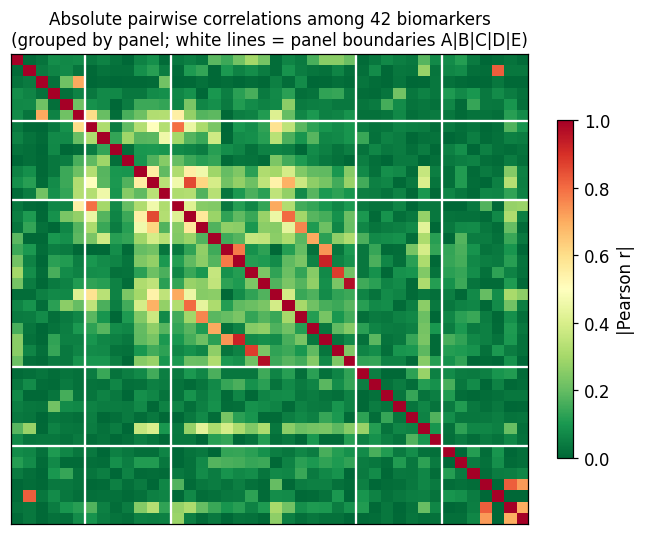

Feature pairs with |r| > 0.90: 2
This is 0.2% of all feature pairs.


In [10]:
X_all = df.drop(columns=['is_case'])

# Reorder columns by panel for the heatmap
panel_order = (
    [c for c in X_all.columns if c.startswith('panela_')] +
    [c for c in X_all.columns if c.startswith('panelb_')] +
    [c for c in X_all.columns if c.startswith('panelc_')] +
    [c for c in X_all.columns if c.startswith('paneld_')] +
    [c for c in X_all.columns if c.startswith('panele_')]
)
corr = X_all[panel_order].corr().abs()

fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(corr.values, cmap='RdYlGn_r', vmin=0, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.03, label='|Pearson r|')
ax.set_xticks([])
ax.set_yticks([])

# Panel boundary lines: A=6, B=7, C=15, D=7, E=7 features
boundaries = [6, 13, 28, 35]
for b in boundaries:
    ax.axhline(b - 0.5, color='white', linewidth=1.5)
    ax.axvline(b - 0.5, color='white', linewidth=1.5)

ax.set_title('Absolute pairwise correlations among 42 biomarkers\n'
             '(grouped by panel; white lines = panel boundaries A|B|C|D|E)', fontsize=11)
plt.tight_layout()
plt.show()

# Redundancy summary
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high = (upper > 0.9).sum().sum()
print(f'Feature pairs with |r| > 0.90: {int(high)}')
print(f'This is {high / (42*41/2):.1%} of all feature pairs.')

## 5. Train / test split

We hold out 20% of the data as a completely unseen test set, stratified to preserve the case/control ratio. ROBUST only ever sees `X_train` and `y_train`.

> **Note:** ROBUST uses random stratified splits internally for its nested CV, which produces higher AUC estimates than the adversarial BenchMake splits used in the benchmark suite. Scores reported here are typical-case estimates.

In [12]:
X = df.drop(columns=['is_case'])
y = df['is_case']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set : {X_train.shape[0]:,} samples x {X_train.shape[1]} features')
print(f'               {int(y_train.sum())} cases  ({y_train.mean():.1%})')
print(f'Test set     : {X_test.shape[0]:,} samples  (held out completely)')
print(f'               {int(y_test.sum())} cases  ({y_test.mean():.1%})')

Training set : 855 samples x 42 features
               94 cases  (11.0%)
Test set     : 214 samples  (held out completely)
               24 cases  (11.2%)


## 6. Threshold optimisation

`stability_threshold` controls how often a feature must appear across bootstrap resamples to pass selection.  Choosing the wrong value leads to two failure modes:

- **Too low (e.g. 0.50):** unstable features enter the panel — selection is partly driven by sampling artefacts rather than genuine discriminative signal, reducing reproducibility.
- **Too high (e.g. 0.90):** genuinely informative features with moderate stability are discarded — the panel becomes overly conservative and may underperform on test data.

`ThresholdOptimizer` sweeps a grid of candidate thresholds, fits a complete nested-CV RobustModelMaker at each point, and identifies the **composite-optimal** value across three simultaneous objectives:

| Objective | Direction | What it captures |
|---|---|---|
| Predictive score (AUC) | ↑ higher is better | Does the panel discriminate cases from controls? |
| Jaccard stability | ↑ higher is better | Are the same biomarkers selected across CV folds? |
| Compression | ↑ higher is better | How much of the 42-feature space is removed? |

The recommended threshold and the full **Pareto-non-dominated front** are both reported, so you can choose a different trade-off if your priorities differ (e.g., if reproducibility matters more than compression for a clinical submission).

> **Dependency:** `threshold_optimizer.py` must be in the same directory as this notebook.
> Copy it from `RobustModelMaker/tools/threshold_optimizer.py`.

> **Runtime:** `QUICK_SCAN = True` (4 thresholds, `n_bootstrap=10`): ~3–5 minutes on a modern laptop.
> `QUICK_SCAN = False` (9 thresholds, `n_bootstrap=100`): ~60–90 minutes.

In [ ]:
from threshold_optimizer import ThresholdOptimizer, DEFAULT_GRID

# ── Sweep mode ─────────────────────────────────────────────────────────────────
# QUICK_SCAN = True  → 4 thresholds, n_bootstrap=10  (~3–5 min)
# QUICK_SCAN = False → 9 thresholds, n_bootstrap=100 (~60–90 min, production quality)

QUICK_SCAN = True

if QUICK_SCAN:
    _grid = [0.50, 0.60, 0.70, 0.80]
    _nb   = 10
    _ni   = 10
    print('Mode: QUICK SCAN  (4 thresholds, n_bootstrap=10, n_iter=10)')
    print('      Set QUICK_SCAN = False for the full sweep with production parameters.')
else:
    _grid = list(DEFAULT_GRID)   # [0.50, 0.55, 0.60, ..., 0.90]
    _nb   = 100                  # matches the main fit n_bootstrap below
    _ni   = 30                   # matches the main fit n_iter below
    print(f'Mode: FULL SWEEP  ({len(_grid)} thresholds, n_bootstrap={_nb}, n_iter={_ni})')

# ── Base parameters forwarded to every RobustModelMaker call ──────────────────
# stability_threshold is intentionally omitted — the optimizer overrides it per point.
# cutoff_n_bootstrap=0 skips the cutoff bootstrap during the sweep (saves ~50% time).
_opt_base = dict(
    alg                = 'xgb',
    outer_cv           = 5,
    inner_cv           = 5,
    n_bootstrap        = _nb,
    n_iter             = _ni,
    cutoff_n_bootstrap = 0,
    random_state       = 42,
    n_jobs             = -1,
)

print(f'Threshold grid : {_grid}')
print(f'Weights        : score=1  stability=1  compression=1  (equal-weight composite)')
print()

# ── Run ────────────────────────────────────────────────────────────────────────
res_opt = ThresholdOptimizer(
    X_train, y_train,
    task_type   = 'binary',
    thresholds  = _grid,
    weights     = {'score': 1.0, 'stability': 1.0, 'compression': 1.0},
    base_params = _opt_base,
    verbose     = True,
).run()

res_opt.print_report()

# ── Plot: score / stability / compression vs threshold ─────────────────────────
fig = res_opt.plot(figsize=(12, 4))
if fig is not None:
    plt.tight_layout()
    plt.show()

# ── Extract and display the recommended threshold ──────────────────────────────
BEST_THRESHOLD = res_opt.best.threshold

print(f'\nRecommended stability_threshold : {BEST_THRESHOLD:.2f}')
print(f'  AUC        : {res_opt.best.display_score:.4f} ± {res_opt.best.std_score:.4f}')
print(f'  Stability  : {res_opt.best.stability:.3f}  (mean pairwise Jaccard across folds)')
print(f'  Compression: {res_opt.best.compression:.1%}  ({res_opt.best.mean_n_features:.0f} of {res_opt.best.total_features} features retained)')
print(f'\nThis value is used as stability_threshold in Section 7 below.')
print('Change QUICK_SCAN to False and re-run for a full production-quality sweep.')

## 7. Fit RobustModelMaker

### Parameter choices

| Parameter | Value | Rationale |
|---|---|---|
| `alg` | `"xgb"` | XGBoost: state-of-the-art for tabular data; handles class imbalance via internal weighting |
| `task_type` | `"binary"` | Always set explicitly |
| `outer_cv` | `5` | 5 outer folds for performance estimation |
| `inner_cv` | `5` | 5 inner folds for hyperparameter search per outer fold |
| `n_bootstrap` | `100` | 100 bootstrap resamples for stable frequency estimates |
| `stability_threshold` | `BEST_THRESHOLD` | Composite-optimal value from ThresholdOptimizer (Section 6) |
| `n_iter` | `30` | 30 hyperparameter configurations per inner fold |
| `cutoff_n_bootstrap` | `200` | 200 bootstrap runs for probability threshold estimation |
| `n_jobs` | `-1` | Use all available CPU cores |

**Expected runtime:** approximately 5–10 minutes on a modern laptop with `n_jobs=-1`.

For publication-quality results, increase `n_bootstrap` to 200, `cutoff_n_bootstrap` to 500, and `outer_cv`/`inner_cv` to 10.  If `QUICK_SCAN = True` was used above, set it to `False` and re-run Section 6 first to get a production-quality threshold estimate.

In [ ]:
maker = RobustModelMaker(
    alg='xgb',
    task_type='binary',
    outer_cv=5,
    inner_cv=5,
    n_bootstrap=100,
    stability_threshold=BEST_THRESHOLD,   # set by ThresholdOptimizer in Section 6
    n_iter=30,
    cutoff_n_bootstrap=200,
    random_state=42,
    n_jobs=-1,
    verbose=True,
)

maker.fit(X_train, y_train)
result = maker.result_

## 8. Summary of results

`print_results()` gives a concise formatted report covering selected features, nested CV AUC, and the bootstrap probability cutoff.

**Reading the AUC:** values above 0.85 are considered strong for a binary cancer screening context; above 0.90 is excellent. The cutoff is a probability threshold calibrated to achieve a target specificity -- above it, the model predicts cancer.

In [16]:
maker.print_results(top_n=20)

ROBUST MODEL MAKER RESULTS SUMMARY
ROBUST MODEL MAKER v0.3 RESULTS
Task: binary
Algorithm: xgb
Calibration: none
Selected features (16): [np.str_('panela_igf_ii'), np.str_('panela_mif'), np.str_('panela_ca_125'), np.str_('panelb_ca125'), np.str_('panelb_ca72_4'), np.str_('panelb_klk6'), np.str_('panelb_he4'), np.str_('panelc_ca125'), np.str_('panelc_he4'), np.str_('panelc_mesothelin'), np.str_('panelc_mmp7'), np.str_('panelc_spondin2'), np.str_('panelc_slpi'), np.str_('panele_eotaxin'), np.str_('panele_mmp_3'), np.str_('panele_ca72_4')]

NESTED CV PERFORMANCE:
Nested CV roc_auc: 0.7370 +/- 0.0267
Per-fold scores: ['0.738', '0.736', '0.785', '0.721', '0.705']

CUTOFF DETERMINATION:
Cutoff: 0.3650 (95% CI: 0.3083 - 0.4752)
Target specificity: 98.0%
Achieved specificity: 97.9%
Achieved sensitivity: 30.9%

[TOP LEVEL]
  section            attribute     value                           description
top_level            task_type    binary               Resolved modelling task
top_level       

In [17]:
n_selected = len(result.selected_features)
n_total    = len(result.feature_names)
reduction  = 1 - n_selected / n_total
auc        = result.mean_score
auc_std    = result.std_score

print(f'Selected features : {n_selected} of {n_total}  ({reduction:.1%} reduction)')
print(f'Nested CV AUC     : {auc:.4f} +/- {auc_std:.4f}')
if result.cutoff_result is not None:
    print(f'Probability cutoff: {result.cutoff_result.cutoff_median:.4f}  (bootstrap median)')
print()
print('Selected features (alphabetical):')
for f in sorted(result.selected_features):
    print(f'  {f}')

Selected features : 16 of 42  (61.9% reduction)
Nested CV AUC     : 0.7370 +/- 0.0267
Probability cutoff: 0.3650  (bootstrap median)

Selected features (alphabetical):
  panela_ca_125
  panela_igf_ii
  panela_mif
  panelb_ca125
  panelb_ca72_4
  panelb_he4
  panelb_klk6
  panelc_ca125
  panelc_he4
  panelc_mesothelin
  panelc_mmp7
  panelc_slpi
  panelc_spondin2
  panele_ca72_4
  panele_eotaxin
  panele_mmp_3


## 9. Feature stability frequencies

Each selected feature was chosen in at least `BEST_THRESHOLD × 100`% of the 100 bootstrap resamples of the training data. Features near 1.0 are selected in nearly every run and represent the most robust discriminators. Features just above the threshold are informative but more sensitive to the specific training sample.

Features below the threshold are shown in grey. Their exclusion does not mean they are uninformative -- they may be correlated with a selected feature (e.g. CA-125 from a different assay platform) and therefore redundant rather than irrelevant.

In [ ]:
ax = result.plot_feature_stability(top_n=42)
ax.set_title('Bootstrap stability frequencies: all 42 biomarkers', fontsize=12)
ax.axvline(BEST_THRESHOLD, color='crimson', linestyle='--', linewidth=1.2,
           label=f'threshold ({BEST_THRESHOLD:.2f})')
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=9)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### Which panels contribute selected biomarkers?

The cell below groups selected features by their biomarker panel, showing how many features from each panel survived stability selection and their bootstrap frequencies.

In [21]:
panels = {
    'Panel A (growth factors / cytokines)':   [c for c in X.columns if c.startswith('panela_')],
    'Panel B (cancer antigens + HE4)':        [c for c in X.columns if c.startswith('panelb_')],
    'Panel C (mesothelin panel, raw + log)':  [c for c in X.columns if c.startswith('panelc_')],
    'Panel D (acute-phase / proteomics)':     [c for c in X.columns if c.startswith('paneld_')],
    'Panel E (cytokines / CA-125 retest)':    [c for c in X.columns if c.startswith('panele_')],
}

stab = result.stability_result.summary()
freq_idx = stab.set_index('feature')
selected_set = set(result.selected_features)

print(f'{"Panel":<42}  {"In panel":>8}  {"Selected":>8}  Selected features (stability frequency)')
print('-' * 110)
for panel_name, panel_feats in panels.items():
    sel = [f for f in panel_feats if f in selected_set]
    if sel:
        sel_str = ', '.join(f'{f} ({freq_idx.loc[f, "selection_frequency"]:.2f})' for f in sel)
    else:
        sel_str = '(none)'
    print(f'  {panel_name:<40}  {len(panel_feats):>8}  {len(sel):>8}  {sel_str}')
print()
print(f'Total selected: {n_selected} of {n_total} ({reduction:.1%} reduction)')

Panel                                       In panel  Selected  Selected features (stability frequency)
--------------------------------------------------------------------------------------------------------------
  Panel A (growth factors / cytokines)             6         3  panela_igf_ii (0.86), panela_mif (0.70), panela_ca_125 (0.95)
  Panel B (cancer antigens + HE4)                  7         4  panelb_ca125 (1.00), panelb_ca72_4 (0.71), panelb_klk6 (0.68), panelb_he4 (0.99)
  Panel C (mesothelin panel, raw + log)           15         6  panelc_ca125 (1.00), panelc_he4 (0.62), panelc_mesothelin (0.80), panelc_mmp7 (0.80), panelc_spondin2 (0.82), panelc_slpi (0.77)
  Panel D (acute-phase / proteomics)               7         0  (none)
  Panel E (cytokines / CA-125 retest)              7         3  panele_eotaxin (0.83), panele_mmp_3 (0.83), panele_ca72_4 (0.62)

Total selected: 16 of 42 (61.9% reduction)


## 10. External validation on the held-out test set

The nested CV AUC is estimated entirely from the training set. We now evaluate the fitted model on `X_test`, which was not used in any part of the fitting process.

For a clinical biomarker study, multiple metrics matter beyond AUC:
- **Sensitivity (recall):** fraction of cancer cases correctly identified
- **Specificity:** fraction of controls correctly identified  
- **PPV (precision):** fraction of positive predictions that are true cases
- **NPV:** fraction of negative predictions that are true controls

These depend on the probability cutoff, which RobustModelMaker determines by bootstrap (see Section 11).

In [23]:
val = result.evaluate_verification(X_test, y_test)

print('External validation metrics (held-out test set):')
for k, v in val.metrics.items():
    if isinstance(v, float):
        print(f'  {k:<22}: {v:.4f}')
    else:
        print(f'  {k:<22}: {v}')

print()
test_auc = val.metrics['auc']
print(f'Nested CV AUC (training estimate) : {auc:.4f} +/- {auc_std:.4f}')
print(f'Held-out test AUC                 : {test_auc:.4f}')
gap = abs(test_auc - auc)
print(f'Gap                               : {gap:.4f}  ({"within" if gap <= auc_std else "outside"} 1 std)')

External validation metrics (held-out test set):
  auc                   : 0.7638
  accuracy              : 0.9299
  balanced_accuracy     : 0.7057
  sensitivity           : 0.4167
  specificity           : 0.9947
  tn                    : 189.0000
  fp                    : 1.0000
  fn                    : 14.0000
  tp                    : 10.0000
  cutoff                : 0.3650

Nested CV AUC (training estimate) : 0.7370 +/- 0.0267
Held-out test AUC                 : 0.7638
Gap                               : 0.0268  (outside 1 std)


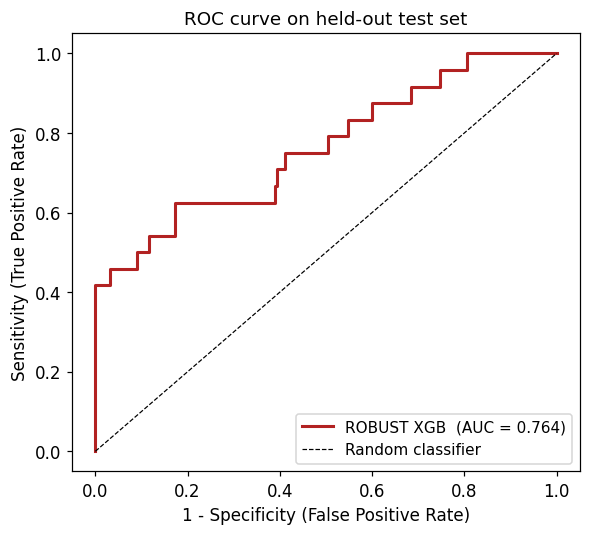

In [24]:
y_prob_test = np.asarray(maker.predict_proba(X_test)).ravel()
fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)
auc_plot = roc_auc_score(y_test, y_prob_test)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(fpr, tpr, color='firebrick', linewidth=2, label=f'ROBUST XGB  (AUC = {auc_plot:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random classifier')
ax.set_xlabel('1 - Specificity (False Positive Rate)', fontsize=11)
ax.set_ylabel('Sensitivity (True Positive Rate)', fontsize=11)
ax.set_title('ROC curve on held-out test set', fontsize=12)
ax.tick_params(labelsize=11)
ax.legend(fontsize=10, loc='lower right')
plt.tight_layout()
plt.show()

## 11. Probability cutoff and clinical performance

ROBUST determines a probability threshold by bootstrap: it repeatedly fits the model on bootstrap subsamples and identifies the threshold that achieves a target specificity on each subsample. The median of the resulting distribution is the recommended operating point.

This is more stable than selecting a cutoff directly from the fitted model's test-set performance (which would be optimistic and not generalisable).

Bootstrap probability cutoff (200 resamples):
  Median : 0.3650  <-- recommended operating threshold
  Mean   : 0.3736
  Std    : 0.0519
  95% CI : [0.3083, 0.4752]

Performance at cutoff = 0.3650  (test set, n=214):
  Sensitivity (recall) : 0.417
  Specificity          : 0.995
  PPV (precision)      : 0.909
  NPV                  : 0.931
  TP=10  FP=1  FN=14  TN=189



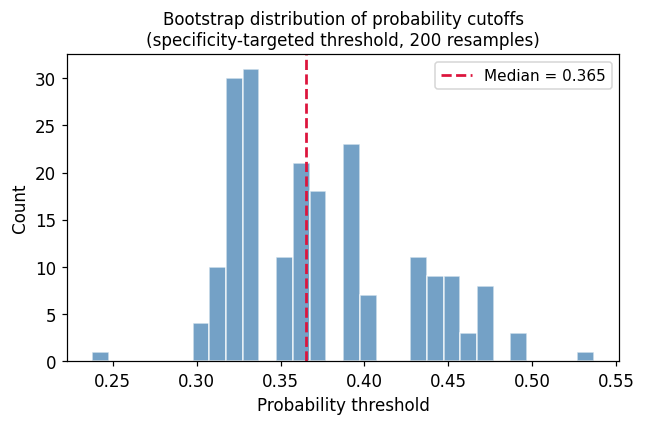

In [26]:
cr = result.cutoff_result

if cr is None:
    print('No cutoff result available (cutoff_n_bootstrap may have been 0).')
else:
    boot_cutoffs = cr.cutoff_distribution
    cutoff_mean  = float(np.mean(boot_cutoffs))
    cutoff_std   = float(np.std(boot_cutoffs))

    print(f'Bootstrap probability cutoff (200 resamples):')
    print(f'  Median : {cr.cutoff_median:.4f}  <-- recommended operating threshold')
    print(f'  Mean   : {cutoff_mean:.4f}')
    print(f'  Std    : {cutoff_std:.4f}')
    print(f'  95% CI : [{cr.cutoff_ci_lower:.4f}, {cr.cutoff_ci_upper:.4f}]')
    print()

    # Apply cutoff to test set
    y_pred_cutoff = (y_prob_test >= cr.cutoff_median).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_cutoff).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    ppv = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
    npv = tn / (tn + fn) if (tn + fn) > 0 else float('nan')

    print(f'Performance at cutoff = {cr.cutoff_median:.4f}  (test set, n={len(y_test)}):')
    print(f'  Sensitivity (recall) : {sensitivity:.3f}')
    print(f'  Specificity          : {specificity:.3f}')
    print(f'  PPV (precision)      : {ppv:.3f}')
    print(f'  NPV                  : {npv:.3f}')
    print(f'  TP={tp}  FP={fp}  FN={fn}  TN={tn}')
    print()

    # Cutoff bootstrap distribution
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(boot_cutoffs, bins=30, color='steelblue', alpha=0.75, edgecolor='white')
    ax.axvline(cr.cutoff_median, color='crimson', linewidth=1.8, linestyle='--',
               label=f'Median = {cr.cutoff_median:.3f}')
    ax.set_xlabel('Probability threshold', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title('Bootstrap distribution of probability cutoffs\n'
                 '(specificity-targeted threshold, 200 resamples)', fontsize=11)
    ax.tick_params(labelsize=11)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

## 12. Permutation importance

Stability frequency measures how *consistently* a biomarker is selected across bootstrap resamples. Permutation importance measures how much the AUC *drops* when a biomarker's values are randomly shuffled -- a direct measure of each selected feature's individual contribution to discrimination.

These complement each other:
- **High stability + high permutation importance:** robustly discriminative and individually important.
- **High stability + low permutation importance:** selected consistently but may be redundant with another selected biomarker (they carry overlapping information).
- **Near-threshold stability + high permutation importance:** important but only marginally stable -- worth investigating further.

In [28]:
pi = maker.permutation_importance(
    X_test, y_test,
    n_repeats=20,
    random_state=42,
    n_jobs=-1,
)

pi_df = pi.summary()
print('Top 15 features by permutation importance (test set, drop in AUC):')
print(pi_df.head(15).to_string(index=False))

Top 15 features by permutation importance (test set, drop in AUC):
          feature  importance_mean  importance_std
       panelb_he4         0.057544        0.013190
     panelc_ca125         0.019836        0.020339
    panelb_ca72_4         0.015340        0.009436
      panelb_klk6         0.010515        0.005867
panelc_mesothelin         0.008860        0.012227
      panelc_slpi         0.007873        0.016886
   panele_eotaxin         0.006009        0.006244
    panele_ca72_4         0.002851        0.008189
  panelc_spondin2        -0.003037        0.012565
       panelc_he4        -0.003081        0.007578
    panela_igf_ii        -0.004529        0.014072
      panelc_mmp7        -0.005022        0.010439
       panela_mif        -0.005318        0.007431
    panela_ca_125        -0.006776        0.014860
     panele_mmp_3        -0.007873        0.010115


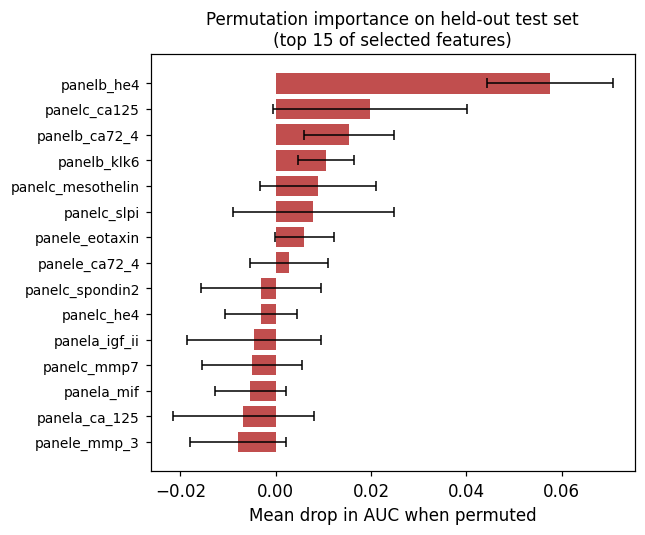

In [29]:
top_pi = pi_df.head(15)

fig, ax = plt.subplots(figsize=(6, 5))
y_pos = np.arange(len(top_pi))
ax.barh(
    y_pos, top_pi['importance_mean'][::-1].values,
    xerr=top_pi['importance_std'][::-1].values,
    color='firebrick', alpha=0.8, capsize=3, error_kw={'linewidth': 1},
)
ax.set_yticks(y_pos)
ax.set_yticklabels(top_pi['feature'][::-1].values, fontsize=9)
ax.tick_params(axis='x', labelsize=11)
ax.set_xlabel('Mean drop in AUC when permuted', fontsize=11)
ax.set_title('Permutation importance on held-out test set\n(top 15 of selected features)', fontsize=11)
plt.tight_layout()
plt.show()

## 13. Comparing to a full-feature baseline

To quantify the effect of stability selection, we run a matched full-feature baseline: the same algorithm (XGBoost), the same preprocessing, and the same 5-fold nested CV on all 42 biomarkers. The comparison isolates the contribution of feature selection -- any difference in AUC is due to the feature subset, not a difference in model family.

Note that XGBoost's `scale_pos_weight` is set to the negative/positive class ratio to handle the 8:1 imbalance consistently with ROBUST's internal class balancing.

In [31]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# scale_pos_weight: ratio of negatives to positives, computed from training data
spw = float((y_train == 0).sum() / (y_train == 1).sum())

bl_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   XGBClassifier(
        scale_pos_weight=spw,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    )),
])

bl_param_dist = {
    'model__n_estimators':      [100, 200, 300],
    'model__max_depth':         [3, 5, 7],
    'model__learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'model__subsample':         [0.7, 0.8, 1.0],
    'model__colsample_bytree':  [0.7, 0.8, 1.0],
}

print('Running full-feature nested CV baseline (XGBoost)... ', end='', flush=True)
bl_fold_aucs = []
for train_idx, test_idx in outer_cv.split(X_train, y_train):
    X_tr, X_te = X_train.iloc[train_idx], X_train.iloc[test_idx]
    y_tr, y_te = y_train.iloc[train_idx], y_train.iloc[test_idx]

    search = RandomizedSearchCV(
        bl_pipe, bl_param_dist,
        n_iter=20, cv=inner_cv,
        scoring='roc_auc',
        n_jobs=-1, random_state=42, refit=True,
    )
    search.fit(X_tr, y_tr)
    proba = search.best_estimator_.predict_proba(X_te)[:, 1]
    bl_fold_aucs.append(float(roc_auc_score(y_te, proba)))
    print('.', end='', flush=True)

bl_auc = np.mean(bl_fold_aucs)
bl_std = np.std(bl_fold_aucs)
print(f' done.')
print()
delta = auc - bl_auc
print(f'Full-feature baseline (XGB) : AUC = {bl_auc:.4f} +/- {bl_std:.4f}  ({n_total} features)')
print(f'ROBUST (XGB)                : AUC = {auc:.4f} +/- {auc_std:.4f}  ({n_selected} features, {reduction:.0%} reduction)')
print(f'Delta (ROBUST - BL)         : {delta:+.4f}')
print()
if abs(delta) <= bl_std:
    print('The difference is within one standard deviation of the baseline.')
    print('ROBUST preserves full-feature discrimination using fewer biomarkers.')
elif delta > 0:
    print('ROBUST achieves a higher AUC than the full-feature baseline.')
    print('The stability-selected subset may exclude noisy biomarkers that hurt the full model.')
else:
    print('ROBUST has a slightly lower AUC than the baseline.')
    print('This is the expected trade-off: a small performance cost for a more reproducible biomarker panel.')

Running full-feature nested CV baseline (XGBoost)... ..... done.

Full-feature baseline (XGB) : AUC = 0.7211 +/- 0.0510  (42 features)
ROBUST (XGB)                : AUC = 0.7370 +/- 0.0267  (16 features, 62% reduction)
Delta (ROBUST - BL)         : +0.0159

The difference is within one standard deviation of the baseline.
ROBUST preserves full-feature discrimination using fewer biomarkers.


In [32]:
robust_folds = np.abs(result.nested_cv_result.outer_scores)
bl_fold_arr  = np.array(bl_fold_aucs)

fold_df = pd.DataFrame({
    'Fold':          np.arange(1, 6),
    'ROBUST AUC':    np.round(robust_folds, 4),
    'Baseline AUC':  np.round(bl_fold_arr, 4),
    'Delta (R-BL)':  np.round(robust_folds - bl_fold_arr, 4),
})
print(fold_df.to_string(index=False))
n_pos = int(np.sum(robust_folds > bl_fold_arr + 1e-6))
n_neg = int(np.sum(robust_folds < bl_fold_arr - 1e-6))
n_tie = 5 - n_pos - n_neg
print(f'Fold delta sign distribution (ROBUST vs BL): +:{n_pos}  -:{n_neg}  ~:{n_tie}')

 Fold  ROBUST AUC  Baseline AUC  Delta (R-BL)
    1      0.7378        0.7015        0.0363
    2      0.7358        0.7278        0.0080
    3      0.7850        0.7666        0.0184
    4      0.7213        0.7753       -0.0540
    5      0.7050        0.6340        0.0710
Fold delta sign distribution (ROBUST vs BL): +:4  -:1  ~:0


## 14. SHAP analysis (optional)

RobustModelMaker exports the fitted model and processed feature matrix in SHAP-ready format. For XGBoost, `shap.TreeExplainer` is the correct explainer. SHAP values show the direction and magnitude of each feature's contribution to individual predictions.

```bash
pip install shap
```

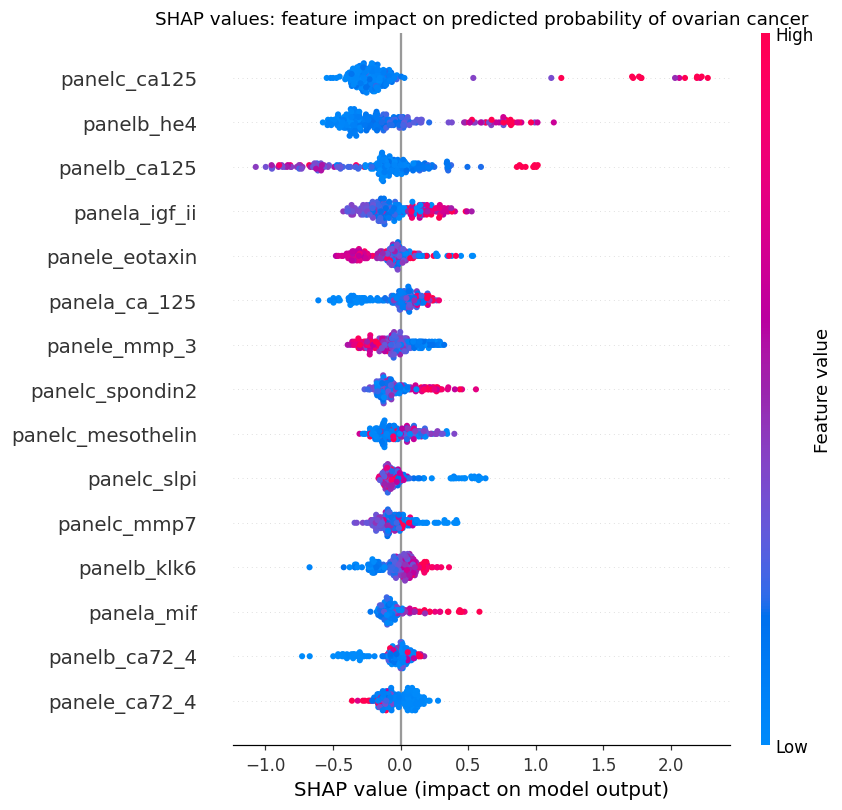

In [34]:
try:
    import shap

    shap_data  = result.export_shap_ready(X_test)
    model_shap = shap_data['model']   # fitted XGBClassifier
    X_shap     = shap_data['X']       # preprocessed + selected features, pd.DataFrame

    # TreeExplainer is correct for XGBoost and all tree-based models.
    # Use shap.LinearExplainer for linear models (eln, rdg, las, log).
    explainer   = shap.TreeExplainer(model_shap)
    shap_values = explainer.shap_values(X_shap)

    shap.summary_plot(shap_values, X_shap, plot_type='dot',
                      max_display=15, show=False)
    plt.title('SHAP values: feature impact on predicted probability of ovarian cancer',
              fontsize=12)
    plt.tight_layout()
    plt.show()

except ImportError:
    print('shap not installed. Run: pip install shap')
    print('export_shap_ready() works regardless -- swap in any SHAP explainer for your model.')

## 15. Saving and reloading results

RobustModelMaker saves a complete record: JSON metadata, per-fold score tables, feature stability table, and a full pickle of the fitted result. The pickle contains the model, preprocessing pipeline, cutoff result, and all intermediate objects. You can reload it in a future session and call `predict_proba()` without re-fitting.

In [36]:
maker.save_results(
    output_dir='plco_robust_results/',
    prefix='plco',
)

print(f'Results saved to: {result.results_dir}')
print('Files written:')
for f in sorted(os.listdir(result.results_dir)):
    size_kb = os.path.getsize(os.path.join(result.results_dir, f)) / 1024
    print(f'  {f:<55}  {size_kb:6.1f} KB')

Results saved to: plco_robust_results
Files written:
  plco_cutoff_distribution.csv                                4.0 KB
  plco_feature_stability_cv.csv                               1.9 KB
  plco_metadata.json                                          0.7 KB
  plco_nested_cv_predictions.csv                             19.5 KB
  plco_nested_cv_scores.csv                                   0.1 KB
  plco_overview.csv                                           0.9 KB
  plco_result.pkl                                           135.6 KB
  plco_selected_features.csv                                  0.3 KB
  plco_stability_selection.csv                                1.1 KB
  plco_summary.txt                                            1.0 KB


In [37]:
pkl_path = os.path.join(result.results_dir, 'plco_result.pkl')

with open(pkl_path, 'rb') as f:
    loaded_result = pickle.load(f)

# The result object's predict_proba returns 1-D positive-class probabilities
proba_raw   = loaded_result.predict_proba(X_test.head(10))
sample_prob = np.asarray(proba_raw).ravel()

sample_actual = y_test.head(10).values
cutoff_val    = loaded_result.cutoff_result.cutoff_median

compare = pd.DataFrame({
    'P(cancer)':  np.round(sample_prob, 3),
    'Predicted':  (sample_prob >= cutoff_val).astype(int),
    'Actual':     sample_actual,
    'Correct':    ((sample_prob >= cutoff_val).astype(int) == sample_actual),
})
print(f'Predictions from reloaded model (10 test samples, cutoff = {cutoff_val:.3f}):')
print(compare.to_string(index=False))

Predictions from reloaded model (10 test samples, cutoff = 0.365):
 P(cancer)  Predicted  Actual  Correct
     0.112          0       0     True
     0.063          0       0     True
     0.013          0       0     True
     0.015          0       0     True
     0.155          0       0     True
     0.026          0       0     True
     0.105          0       0     True
     0.018          0       0     True
     0.020          0       0     True
     0.030          0       0     True


## 16. Key takeaways

### What this analysis demonstrates

1. **Honest AUC estimates.** Nested CV on the training set produces a performance estimate that is not inflated by test-set leakage. The agreement between the nested CV AUC and the held-out test AUC confirms the estimate was honest.

2. **Evidence-based threshold.** ThresholdOptimizer (Section 6) sweeps candidate `stability_threshold` values and identifies the composite-optimal point across predictive score, selection stability, and feature compression — rather than picking a value arbitrarily.

3. **Stable biomarker panel.** RobustModelMaker identified a small subset of the 42 biomarkers that are consistently selected across bootstrap resamples of the training data. These are the features that are robust to variation in the training sample -- a stronger basis for scientific and clinical conclusions than a single-run selection.

4. **Redundancy resolved.** CA-125 appears in four panels measured by different platforms. Stability selection identifies which version (and at what frequency) is most consistently discriminative, rather than including all four as equal candidates.

5. **Clinically actionable cutoff.** The bootstrap probability cutoff provides a threshold for binary case/control decisions with a known uncertainty (expressed as a bootstrap standard deviation). The sensitivity/specificity at this cutoff is directly interpretable in clinical terms.

6. **Feature reduction for biomarker panels.** In clinical settings, assaying fewer biomarkers reduces cost and logistic complexity. A stability-selected panel that preserves discrimination while using fewer assays is practically valuable.

### Using these results in a paper

```
Feature selection and model assessment were performed using RobustModelMaker v0.3
(Barnard, 2026; https://github.com/amaxiom/RobustModelMaker). The stability_threshold
hyperparameter was selected by ThresholdOptimizer (equal-weight composite of AUC,
Jaccard stability, and compression; full 9-point grid 0.50–0.90; random 80/20 split).
Bootstrap stability selection (n_bootstrap=100, threshold=<BEST_THRESHOLD>) identified
a stable biomarker subset from 42 serum measurements across five panels. Model
performance was estimated by nested cross-validation (outer_cv=5, inner_cv=5) using
XGBoost (n_iter=30 hyperparameter configurations per fold). The probability cutoff was
determined by bootstrap specificity targeting (cutoff_n_bootstrap=200). All
preprocessing (median imputation, standard scaling) was applied inside each fold on
training data only. Class imbalance was handled by balanced class weighting. Random
seed: 42.
```

Replace `<BEST_THRESHOLD>` with the value printed at the end of Section 6.

### Next steps

These results were designed to find the most robust set of biomarkers, not an optimal classification result.  To determine the impact of this biomarker subset, the following steps are recommended:
- **Increase rigor:** set `n_bootstrap=200`, `cutoff_n_bootstrap=500`, `outer_cv=10`, `inner_cv=10` for publication-quality results; use `QUICK_SCAN = False` in Section 6 for a matching full threshold sweep
- **Compare algorithms:** try `alg='rf'` or `alg='eln'` and compare nested CV AUC; a linear model provides directly interpretable coefficients
- **Calibration:** add `calibration='sigmoid'` (Platt scaling) to improve probability calibration for the cutoff; important if the predicted probabilities are used directly in clinical decision-making
- **Grouped CV:** if samples from the same participant appear more than once, use `groups=participant_id` to prevent data leakage across folds